# Age regression from brain MRI

Predicting the age of a patient from their brain MRI scan can have diagnostic value for a number of diseases that may cause structural changes and potential damage to the brain. A discrepancy between the predicted age and the real, chronological age of a patient might indicate the presence of disease. This requires an accurate predictor of brain age which may be learned from a set of healthy reference subjects, given their brain MRI data and their actual age.



# about the data

The following cells provide some helper functions to load the data, and provide some overview and visualisation of the statistics over the total population of 652 subjects. The data will be split into different subsets to be used for different parts of the coursework. There is a set of 52 subjects to be used in part A to develop an image segmentation method (47 for training, 5 for validation). We then use 500 subjects for training and two-fold cross-validation of age regression approaches in part A and B.

### Install SimpleITK

In [11]:
!pip install SimpleITK seaborn tqdm

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Setting data directory

In [12]:
# data directory
data_dir = '/content/drive/MyDrive/data/brain_age/'

Let's start by loading the meta data of the entire population, that is the data containing information about the subject IDs, their age, and gender.

In [13]:
# Read the meta data using pandas
import pandas as pd

meta_data_all = pd.read_csv('/content/drive/MyDrive/data/brain_age/meta/meta_data_all.csv')
meta_data_all.head() # show the first five data entries

,subject_id,age,gender_code,gender_text
0,CC110033,24,1,MALE
1,CC110037,18,1,MALE
2,CC110045,24,2,FEMALE
3,CC110056,22,2,FEMALE
4,CC110062,20,1,MALE


Let's have a look at some population statistics.

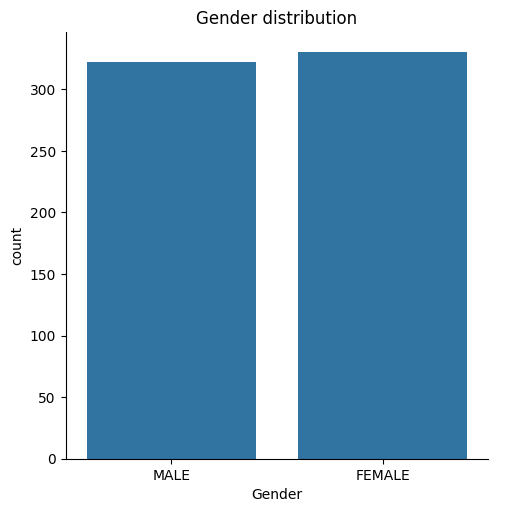

<ipython-input-14-3bf90b78a0b7>:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(meta_data['age'], bins=[10,20,30,40,50,60,70,80,90])


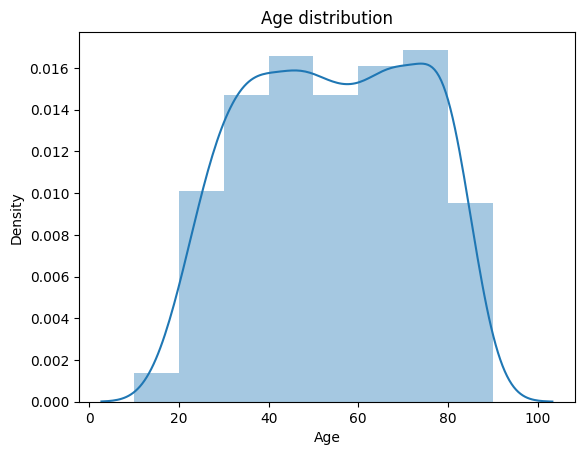

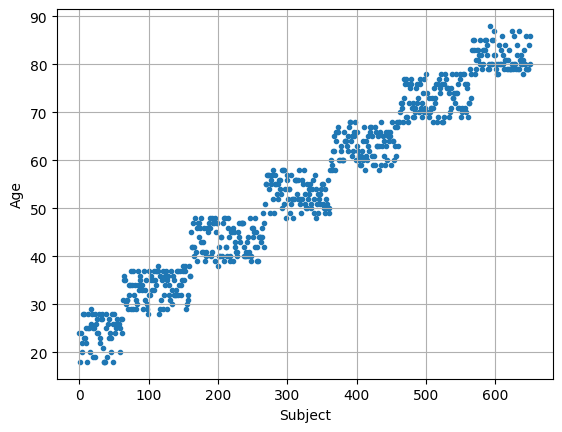

In [14]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

meta_data = meta_data_all

sns.catplot(x="gender_text", data=meta_data, kind="count")
plt.title('Gender distribution')
plt.xlabel('Gender')
plt.show()

sns.distplot(meta_data['age'], bins=[10,20,30,40,50,60,70,80,90])
plt.title('Age distribution')
plt.xlabel('Age')
plt.show()

plt.scatter(range(len(meta_data['age'])),meta_data['age'], marker='.')
plt.grid()
plt.xlabel('Subject')
plt.ylabel('Age')
plt.show()

### Set up a simple medical image viewer and import SimpleITK

In [15]:

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

from ipywidgets import interact, fixed
from IPython.display import display

# Calculate parameters low and high from window and level
def wl_to_lh(window, level):
    low = level - window/2
    high = level + window/2
    return low,high

def display_image(img, x=None, y=None, z=None, window=None, level=None, colormap='gray', crosshair=False):
    # Convert SimpleITK image to NumPy array
    img_array = sitk.GetArrayFromImage(img)

    # Get image dimensions in millimetres
    size = img.GetSize()
    spacing = img.GetSpacing()
    width  = size[0] * spacing[0]
    height = size[1] * spacing[1]
    depth  = size[2] * spacing[2]

    if x is None:
        x = np.floor(size[0]/2).astype(int)
    if y is None:
        y = np.floor(size[1]/2).astype(int)
    if z is None:
        z = np.floor(size[2]/2).astype(int)

    if window is None:
        window = np.max(img_array) - np.min(img_array)

    if level is None:
        level = window / 2 + np.min(img_array)

    low,high = wl_to_lh(window,level)

    # Display the orthogonal slices
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))

    ax1.imshow(img_array[z,:,:], cmap=colormap, clim=(low, high), extent=(0, width, height, 0))
    ax2.imshow(img_array[:,y,:], origin='lower', cmap=colormap, clim=(low, high), extent=(0, width,  0, depth))
    ax3.imshow(img_array[:,:,x], origin='lower', cmap=colormap, clim=(low, high), extent=(0, height, 0, depth))

    # Additionally display crosshairs
    if crosshair:
        ax1.axhline(y * spacing[1], lw=1)
        ax1.axvline(x * spacing[0], lw=1)
        ax2.axhline(z * spacing[2], lw=1)
        ax2.axvline(x * spacing[0], lw=1)
        ax3.axhline(z * spacing[2], lw=1)
        ax3.axvline(y * spacing[1], lw=1)

    plt.show()

def interactive_view(img):
    size = img.GetSize()
    img_array = sitk.GetArrayFromImage(img)
    interact(display_image,img=fixed(img),
             x=(0, size[0] - 1),
             y=(0, size[1] - 1),
             z=(0, size[2] - 1),
             window=(0,np.max(img_array) - np.min(img_array)),
             level=(np.min(img_array),np.max(img_array)));

### Imaging data

Let's check out the imaging data that is available for each subject. This cell also shows how to retrieve data given a particular subject ID from the meta data.

Imaging data of subject CC110033 with age 24

MR Image


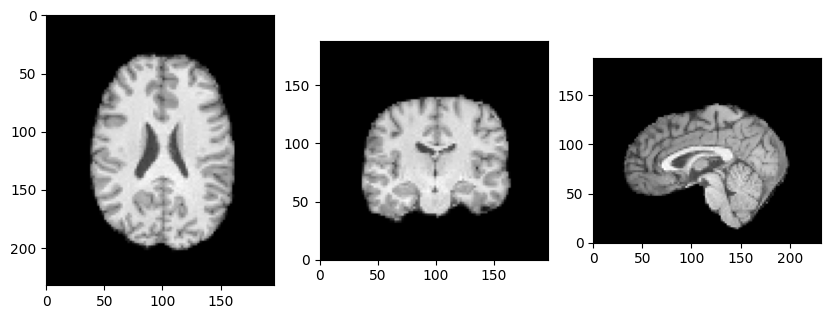

Brain mask


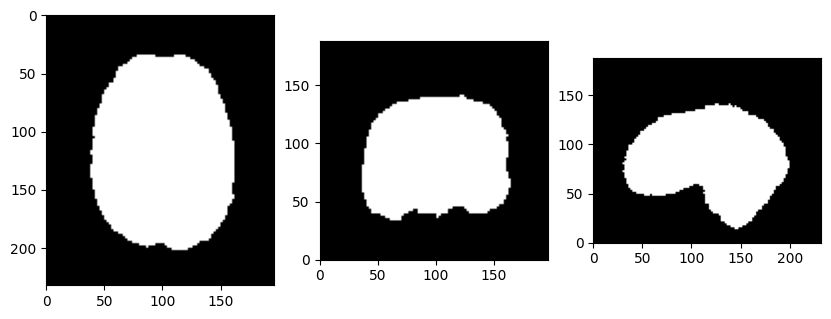

In [16]:
# Subject with index 0
ID = meta_data['subject_id'][0]
age = meta_data['age'][0]

# Image
image_filename = data_dir + 'images/sub-' + ID + '_T1w_unbiased.nii.gz'
img = sitk.ReadImage(image_filename)

# Mask
mask_filename = data_dir + 'masks/sub-' + ID + '_T1w_brain_mask.nii.gz'
msk = sitk.ReadImage(mask_filename)

print('Imaging data of subject ' + ID + ' with age ' + str(age))

print('\nMR Image')
display_image(img, window=400, level=200)

print('Brain mask')
display_image(msk)

## Part A: Age prediction using brain tissue segmentation and volume features

The first approach aims to regress the age of a subject using the volumes of brain tissues as features. The brain tissues include grey matter (GM), white matter (WM), and cerebrospinal fluid (CSF). It is known that with increasing age the ventricles enlarge (filled with CSF), while it is assumed that grey and white matter volume may decrease over time. However, as overall brain volume varies across individuals, taking the absolute volumes of tissues might not be predictive. Instead, relative volumes need to be computed as the ratios between each tissue volume and overall brain volume. To this end, a four-class (GM, WM, CSF, and background) brain segmentation needs to be implemented which will be trained using a total of 52 subjects (47 for training, 5 for validation). The segmentation method is then applied to the remaining 600 brain scans which will be used to train and test the age regression. Brain masks are provided which have been generated with a state-of-the-art neuroimaging brain extraction tool.


### TASK A-1: Brain tissue segmentation

Implementing a CNN model for brain tissue segmentation which can provide segmentations of GM, WM, and CSF. For this task (and only for this task), we provide a subset of 52 subjects which are split into 47 images for training and 5 for validation. The template code below has the data handling and main training routines already implemented, so you can focus on implementing a suitable CNN model. A simple model is provided, but this won't perform very well.



#### Imports

In [17]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

#### Data Helpers

In [18]:
def zero_mean_unit_var(image, mask):
    """Normalizes an image to zero mean and unit variance."""

    img_array = sitk.GetArrayFromImage(image)
    img_array = img_array.astype(np.float32)

    msk_array = sitk.GetArrayFromImage(mask)

    mean = np.mean(img_array[msk_array>0])
    std = np.std(img_array[msk_array>0])

    if std > 0:
        img_array = (img_array - mean) / std
        img_array[msk_array==0] = 0

    image_normalised = sitk.GetImageFromArray(img_array)
    image_normalised.CopyInformation(image)

    return image_normalised


def resample_image(image, out_spacing=(1.0, 1.0, 1.0), out_size=None, is_label=False, pad_value=0):
    """Resamples an image to given element spacing and output size."""

    original_spacing = np.array(image.GetSpacing())
    original_size = np.array(image.GetSize())

    if out_size is None:
        out_size = np.round(np.array(original_size * original_spacing / np.array(out_spacing))).astype(int)
    else:
        out_size = np.array(out_size)

    original_direction = np.array(image.GetDirection()).reshape(len(original_spacing),-1)
    original_center = (np.array(original_size, dtype=float) - 1.0) / 2.0 * original_spacing
    out_center = (np.array(out_size, dtype=float) - 1.0) / 2.0 * np.array(out_spacing)

    original_center = np.matmul(original_direction, original_center)
    out_center = np.matmul(original_direction, out_center)
    out_origin = np.array(image.GetOrigin()) + (original_center - out_center)

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size.tolist())
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(out_origin.tolist())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(pad_value)

    if is_label:
        resample.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(image)


class ImageSegmentationDataset(Dataset):
    """Dataset for image segmentation."""

    def __init__(self, file_list_img, file_list_seg, file_list_msk, img_spacing, img_size):
        self.samples = []
        self.img_names = []
        self.seg_names = []
        for idx, _ in enumerate(tqdm(range(len(file_list_img)), desc='Loading Data')):
            img_path = file_list_img[idx]
            seg_path = file_list_seg[idx]
            msk_path = file_list_msk[idx]

            img = sitk.ReadImage(img_path, sitk.sitkFloat32)

            seg = sitk.ReadImage(seg_path, sitk.sitkInt64)

            msk = sitk.ReadImage(msk_path, sitk.sitkUInt8)

            #pre=processing
            img = zero_mean_unit_var(img, msk)
            img = resample_image(img, img_spacing, img_size, is_label=False)
            seg = resample_image(seg, img_spacing, img_size, is_label=True)
            msk = resample_image(msk, img_spacing, img_size, is_label=True)

            sample = {'img': img, 'seg': seg, 'msk': msk}

            self.samples.append(sample)
            self.img_names.append(os.path.basename(img_path))
            self.seg_names.append(os.path.basename(seg_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, item):
        sample = self.samples[item]
        name = self.img_names[item]

        image = torch.from_numpy(sitk.GetArrayFromImage(sample['img'])).unsqueeze(0)
        seg = torch.from_numpy(sitk.GetArrayFromImage(sample['seg'])).unsqueeze(0)
        msk = torch.from_numpy(sitk.GetArrayFromImage(sample['msk'])).unsqueeze(0)

        return {'img': image, 'seg': seg, 'msk': msk, 'name': name}

    def get_sample(self, item):
        return self.samples[item]

    def get_img_name(self, item):
        return self.img_names[item]

    def get_seg_name(self, item):
        return self.seg_names[item]


#### Check that the GPU is up and running

In [19]:
cuda_dev = '0' #GPU device 0 (can be changed if multiple GPUs are available)

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:" + cuda_dev if use_cuda else "cpu")

print('Device: ' + str(device))
if use_cuda:
    print('GPU: ' + str(torch.cuda.get_device_name(int(cuda_dev))))

Device: cuda:0
GPU: Tesla T4


#### Config and hyper-parameters

Here we set some default hyper-parameters and a starting configuration for the image resolution and others.

**TASK: This needs to be revisited to optimise these values. In particular, you may want to run your final model on higher resolution images.**

In [20]:

rnd_seed = 42 #fixed random seed

img_size = [96, 96, 96]
img_spacing = [2, 2, 2]

num_epochs = 100
learning_rate = 0.001
batch_size = 2
val_interval = 10

num_classes = 4

out_dir = './output'

# Create output directory
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

#### Loading and pre-processing of training and validation data

In [21]:
meta_data_seg_train = pd.read_csv(data_dir + 'meta/meta_data_segmentation_train.csv')
ids_seg_train = list(meta_data_seg_train['subject_id'])
files_seg_img_train = [data_dir + 'images/sub-' + f + '_T1w_unbiased.nii.gz' for f in ids_seg_train]
files_seg_seg_train = [data_dir + 'segs_refs/sub-' + f + '_T1w_seg.nii.gz' for f in ids_seg_train]
files_seg_msk_train = [data_dir + 'masks/sub-' + f + '_T1w_brain_mask.nii.gz' for f in ids_seg_train]

meta_data_seg_val = pd.read_csv(data_dir + 'meta/meta_data_segmentation_val.csv')
ids_seg_val = list(meta_data_seg_val['subject_id'])
files_seg_img_val = [data_dir + 'images/sub-' + f + '_T1w_unbiased.nii.gz' for f in ids_seg_val]
files_seg_seg_val = [data_dir + 'segs_refs/sub-' + f + '_T1w_seg.nii.gz' for f in ids_seg_val]
files_seg_msk_val = [data_dir + 'masks/sub-' + f + '_T1w_brain_mask.nii.gz' for f in ids_seg_val]

We apply some standard pre-processing on the data such as intensity normalization (zero mean unit variance) and downsampling according to the configuration above.

**You may want to use initially the validation data with 5 subjects for training which is more efficient when debugging your training routine and model implementation. Make sure to later train your final model on the actual training data.**

In [38]:
# LOAD TRAINING DATA
dataset_train = ImageSegmentationDataset(files_seg_img_train, files_seg_seg_train, files_seg_msk_train, img_spacing, img_size)
# FOR QUICK DEBUGGING, USE THE VALIDATION DATA FOR TRAINING
#dataset_train = ImageSegmentationDataset(files_seg_img_val, files_seg_seg_val, files_seg_msk_val, img_spacing, img_size)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# LOAD VALIDATION DATA
dataset_val = ImageSegmentationDataset(files_seg_img_val, files_seg_seg_val, files_seg_msk_val, img_spacing, img_size)
dataloader_val = torch.utils.data.DataLoader(dataset_val, batch_size=1, shuffle=False)

Loading Data: 100%|██████████| 5/5 [00:21<00:00,  4.23s/it]


#### Visualise training example

Just to check how a training image looks like after pre-processing.

Image: sub-CC221040_T1w_unbiased.nii.gz


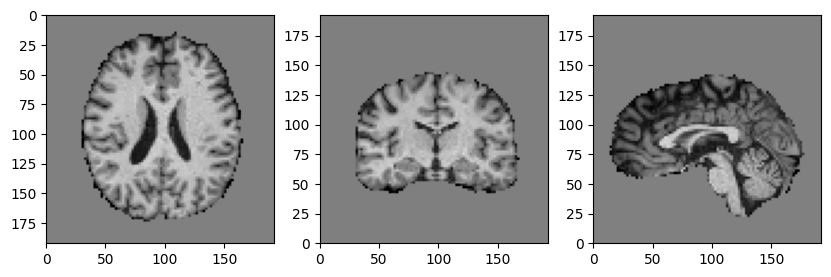

Segmentation


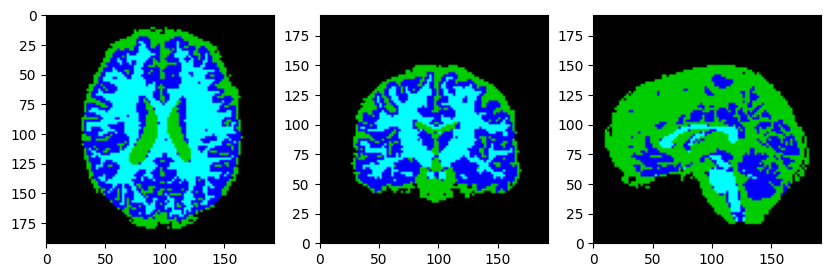

Mask


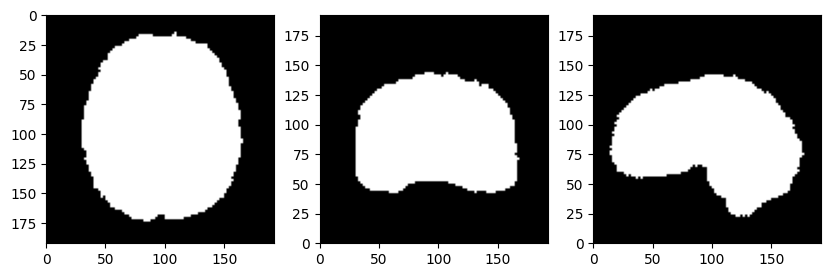

In [39]:
sample = dataset_train.get_sample(0)
img_name = dataset_train.get_img_name(0)
seg_name = dataset_train.get_seg_name(0)
print('Image: ' + img_name)
display_image(sample['img'], window=5, level=0)
print('Segmentation')
display_image(sitk.LabelToRGB(sample['seg']))
print('Mask')
display_image(sample['msk'])

#### The Model

**TASK:** This is the **key part of task A-1** where you have to design a suitable CNN model for brain segmentation. The simple model provided below works to some degree (it let's you run through the upcoming cells), but it will not perform very well. Use what you learned in the lectures to come up with a good architecture. Start with a simple, shallow model and only increase complexity (e.g., number of layers) if needed.

In [40]:

class SimpleNet3D(nn.Module):
    def contraction_block(self, in_channels, out_channels, kernel_size, padding):
        block = nn.Sequential(nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding),
                              nn.ReLU(),
                              nn.BatchNorm3d(out_channels)
        )
        return block

    def expansion_block(self, in_channels, out_channels, kernel_size, padding):
        block = nn.Sequential(nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding),
                              nn.ReLU(),
                              nn.BatchNorm3d(out_channels)
        )
        return block

    def output_block(self, in_channels, out_channels, kernel_size, padding):
        block = nn.Sequential(nn.Conv3d(in_channels, out_channels, kernel_size, padding=padding),
                              nn.ReLU(),
                              nn.BatchNorm3d(out_channels)
        )
        return block

    def __init__(self, num_classes):
        super(SimpleNet3D, self).__init__()
        self.contract1 = self.contraction_block(1, 64, 3, 1)
        self.maxpool = nn.MaxPool3d(kernel_size=2)
        self.contract2 = self.contraction_block(64, 128, 3, 1)
        self.bottleneck = nn.Sequential(nn.Conv3d(128, 256, 3, padding=1),
                                        nn.ReLU(),
                                        nn.BatchNorm3d(256),
                                        nn.Conv3d(256, 128, 3, padding=1),
                                        nn.ReLU(),
                                        nn.BatchNorm3d(128)
        )
        self.convtrans1 = nn.ConvTranspose3d(128, 128, 3, 2, 1, 1)
        self.expand1 = self.expansion_block(256, 64, 3, 1)
        self.convtrans2 = nn.ConvTranspose3d(64, 64, 3, 2, 1, 1)
        self.expand2 = self.expansion_block(128, 16, 3, 1)
        self.output = self.output_block(16, num_classes, 3, 1)

    def forward(self, x):
        x_contract1 = self.contract1(x)
        x_pool1 = self.maxpool(x_contract1)
        x_contract2 = self.contract2(x_pool1)
        x_pool2 = self.maxpool(x_contract2)
        x_bottleneck = self.bottleneck(x_pool2)
        x_convtrans1 = self.convtrans1(x_bottleneck)
        x_cat1 = torch.cat((x_contract2, x_convtrans1), 1)
        x_expand1 = self.expand1(x_cat1)
        x_convtrans2 = self.convtrans2(x_expand1)
        x_cat2 = torch.cat((x_contract1, x_convtrans2), 1)
        x_expand2 = self.expand2(x_cat2)
        x_output = self.output(x_expand2)
        return x_output # cross-entropy loss expects raw logits and applies softmax

#### TRAINING

Below is an implementation of a full training procedure including a loop for intermediate evaluation of the model on the validation data.

START TRAINING...
+ TRAINING 	Epoch: 1 	Loss: 0.766115
--------------------------------------------------
+ VALIDATE 	Epoch: 1 	Loss: 0.785113


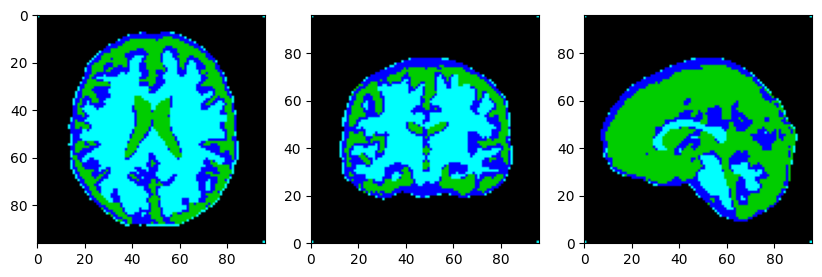

--------------------------------------------------
+ TRAINING 	Epoch: 2 	Loss: 0.731312
+ TRAINING 	Epoch: 3 	Loss: 0.686814
+ TRAINING 	Epoch: 4 	Loss: 0.609733
+ TRAINING 	Epoch: 5 	Loss: 0.623432
+ TRAINING 	Epoch: 6 	Loss: 0.541135
+ TRAINING 	Epoch: 7 	Loss: 0.538236
+ TRAINING 	Epoch: 8 	Loss: 0.490628
+ TRAINING 	Epoch: 9 	Loss: 0.471563
+ TRAINING 	Epoch: 10 	Loss: 0.435444
--------------------------------------------------
+ VALIDATE 	Epoch: 10 	Loss: 0.460261


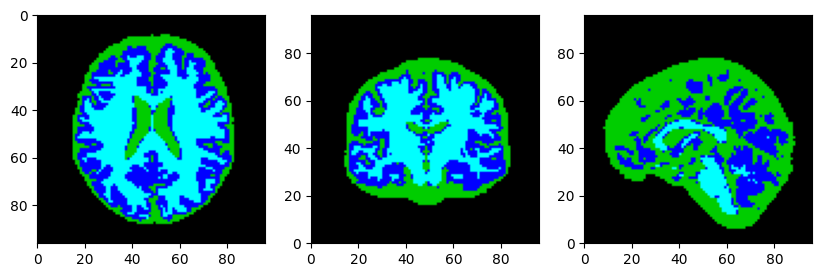

--------------------------------------------------
+ TRAINING 	Epoch: 11 	Loss: 0.444686
+ TRAINING 	Epoch: 12 	Loss: 0.419112
+ TRAINING 	Epoch: 13 	Loss: 0.405691
+ TRAINING 	Epoch: 14 	Loss: 0.410305
+ TRAINING 	Epoch: 15 	Loss: 0.392178
+ TRAINING 	Epoch: 16 	Loss: 0.346095
+ TRAINING 	Epoch: 17 	Loss: 0.380909
+ TRAINING 	Epoch: 18 	Loss: 0.355774
+ TRAINING 	Epoch: 19 	Loss: 0.299917
+ TRAINING 	Epoch: 20 	Loss: 0.309789
--------------------------------------------------
+ VALIDATE 	Epoch: 20 	Loss: 0.311956


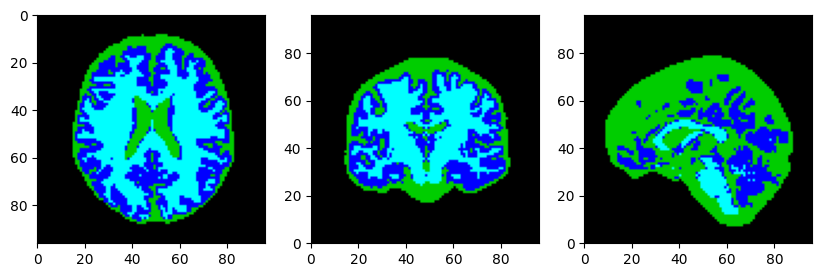

--------------------------------------------------
+ TRAINING 	Epoch: 21 	Loss: 0.315055
+ TRAINING 	Epoch: 22 	Loss: 0.320964
+ TRAINING 	Epoch: 23 	Loss: 0.298365
+ TRAINING 	Epoch: 24 	Loss: 0.313992
+ TRAINING 	Epoch: 25 	Loss: 0.252571
+ TRAINING 	Epoch: 26 	Loss: 0.243348
+ TRAINING 	Epoch: 27 	Loss: 0.234870
+ TRAINING 	Epoch: 28 	Loss: 0.230786
+ TRAINING 	Epoch: 29 	Loss: 0.275310
+ TRAINING 	Epoch: 30 	Loss: 0.246223
--------------------------------------------------
+ VALIDATE 	Epoch: 30 	Loss: 0.231701


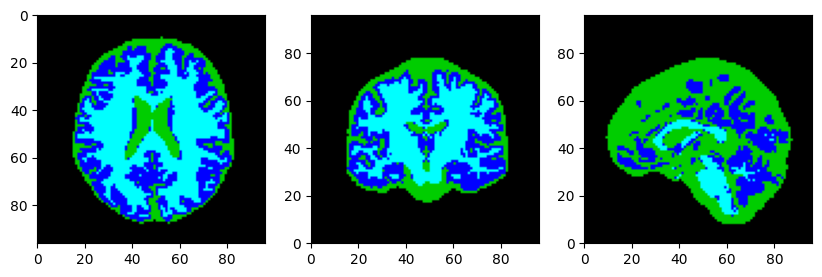

--------------------------------------------------
+ TRAINING 	Epoch: 31 	Loss: 0.223950
+ TRAINING 	Epoch: 32 	Loss: 0.244680
+ TRAINING 	Epoch: 33 	Loss: 0.213820
+ TRAINING 	Epoch: 34 	Loss: 0.196921
+ TRAINING 	Epoch: 35 	Loss: 0.185056
+ TRAINING 	Epoch: 36 	Loss: 0.205872
+ TRAINING 	Epoch: 37 	Loss: 0.196680
+ TRAINING 	Epoch: 38 	Loss: 0.184933
+ TRAINING 	Epoch: 39 	Loss: 0.186706
+ TRAINING 	Epoch: 40 	Loss: 0.171638
--------------------------------------------------
+ VALIDATE 	Epoch: 40 	Loss: 0.182931


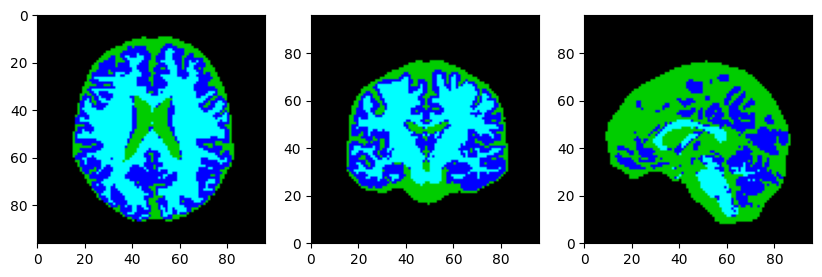

--------------------------------------------------
+ TRAINING 	Epoch: 41 	Loss: 0.164286
+ TRAINING 	Epoch: 42 	Loss: 0.176712
+ TRAINING 	Epoch: 43 	Loss: 0.163804
+ TRAINING 	Epoch: 44 	Loss: 0.203769
+ TRAINING 	Epoch: 45 	Loss: 0.151450
+ TRAINING 	Epoch: 46 	Loss: 0.162582
+ TRAINING 	Epoch: 47 	Loss: 0.144284
+ TRAINING 	Epoch: 48 	Loss: 0.144837
+ TRAINING 	Epoch: 49 	Loss: 0.144151
+ TRAINING 	Epoch: 50 	Loss: 0.138753
--------------------------------------------------
+ VALIDATE 	Epoch: 50 	Loss: 0.145334


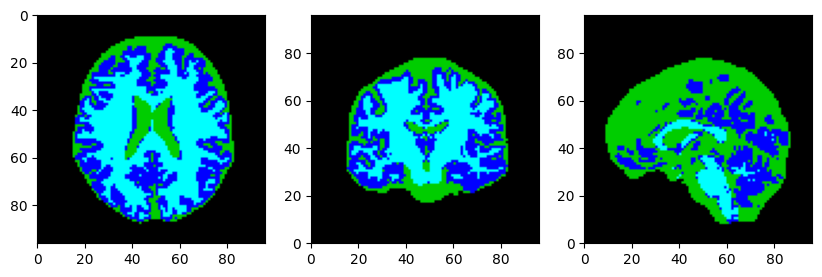

--------------------------------------------------
+ TRAINING 	Epoch: 51 	Loss: 0.134025
+ TRAINING 	Epoch: 52 	Loss: 0.139813
+ TRAINING 	Epoch: 53 	Loss: 0.131487
+ TRAINING 	Epoch: 54 	Loss: 0.133871
+ TRAINING 	Epoch: 55 	Loss: 0.169188
+ TRAINING 	Epoch: 56 	Loss: 0.115853
+ TRAINING 	Epoch: 57 	Loss: 0.120229
+ TRAINING 	Epoch: 58 	Loss: 0.119777
+ TRAINING 	Epoch: 59 	Loss: 0.116659
+ TRAINING 	Epoch: 60 	Loss: 0.113783
--------------------------------------------------
+ VALIDATE 	Epoch: 60 	Loss: 0.124252


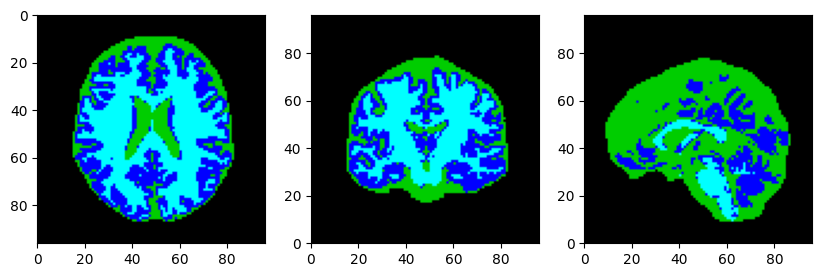

--------------------------------------------------
+ TRAINING 	Epoch: 61 	Loss: 0.111384
+ TRAINING 	Epoch: 62 	Loss: 0.118640
+ TRAINING 	Epoch: 63 	Loss: 0.116179
+ TRAINING 	Epoch: 64 	Loss: 0.114436
+ TRAINING 	Epoch: 65 	Loss: 0.144724
+ TRAINING 	Epoch: 66 	Loss: 0.109017
+ TRAINING 	Epoch: 67 	Loss: 0.113013
+ TRAINING 	Epoch: 68 	Loss: 0.098163
+ TRAINING 	Epoch: 69 	Loss: 0.107284
+ TRAINING 	Epoch: 70 	Loss: 0.094130
--------------------------------------------------
+ VALIDATE 	Epoch: 70 	Loss: 0.108828


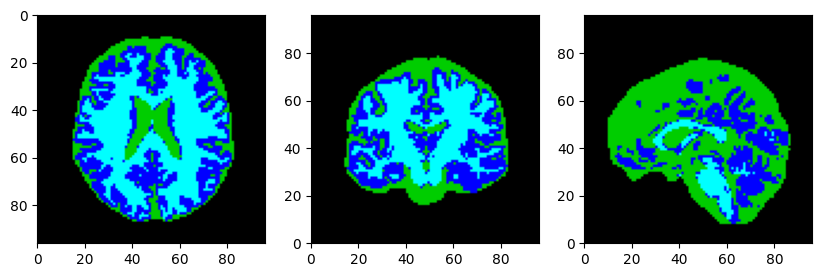

--------------------------------------------------
+ TRAINING 	Epoch: 71 	Loss: 0.091578
+ TRAINING 	Epoch: 72 	Loss: 0.103184
+ TRAINING 	Epoch: 73 	Loss: 0.117722
+ TRAINING 	Epoch: 74 	Loss: 0.093462
+ TRAINING 	Epoch: 75 	Loss: 0.083690
+ TRAINING 	Epoch: 76 	Loss: 0.087325
+ TRAINING 	Epoch: 77 	Loss: 0.082620
+ TRAINING 	Epoch: 78 	Loss: 0.084138
+ TRAINING 	Epoch: 79 	Loss: 0.081938
+ TRAINING 	Epoch: 80 	Loss: 0.108658
--------------------------------------------------
+ VALIDATE 	Epoch: 80 	Loss: 0.098198


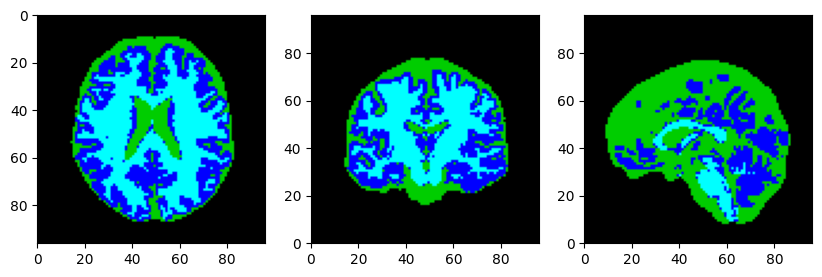

--------------------------------------------------
+ TRAINING 	Epoch: 81 	Loss: 0.079743
+ TRAINING 	Epoch: 82 	Loss: 0.079060
+ TRAINING 	Epoch: 83 	Loss: 0.080836
+ TRAINING 	Epoch: 84 	Loss: 0.079973
+ TRAINING 	Epoch: 85 	Loss: 0.080961
+ TRAINING 	Epoch: 86 	Loss: 0.077482
+ TRAINING 	Epoch: 87 	Loss: 0.075987
+ TRAINING 	Epoch: 88 	Loss: 0.107454
+ TRAINING 	Epoch: 89 	Loss: 0.069416
+ TRAINING 	Epoch: 90 	Loss: 0.077291
--------------------------------------------------
+ VALIDATE 	Epoch: 90 	Loss: 0.091338


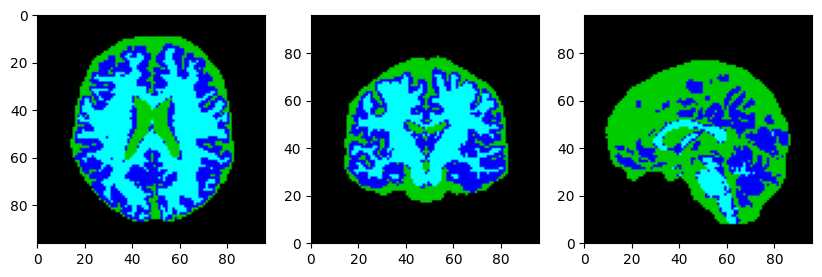

--------------------------------------------------
+ TRAINING 	Epoch: 91 	Loss: 0.069695
+ TRAINING 	Epoch: 92 	Loss: 0.070150
+ TRAINING 	Epoch: 93 	Loss: 0.069479
+ TRAINING 	Epoch: 94 	Loss: 0.069842
+ TRAINING 	Epoch: 95 	Loss: 0.061410
+ TRAINING 	Epoch: 96 	Loss: 0.066092
+ TRAINING 	Epoch: 97 	Loss: 0.068337
+ TRAINING 	Epoch: 98 	Loss: 0.063039
+ TRAINING 	Epoch: 99 	Loss: 0.059939
+ TRAINING 	Epoch: 100 	Loss: 0.067375
--------------------------------------------------
+ VALIDATE 	Epoch: 100 	Loss: 0.086642


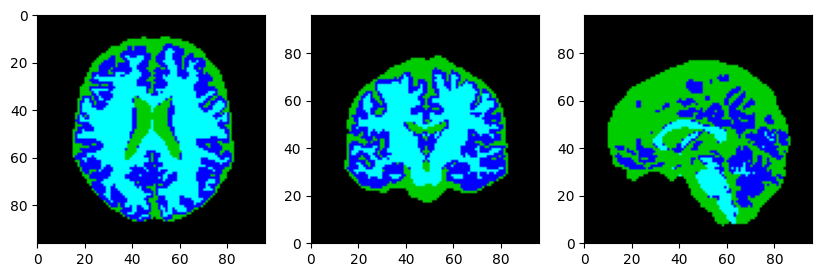

--------------------------------------------------

Finished TRAINING.


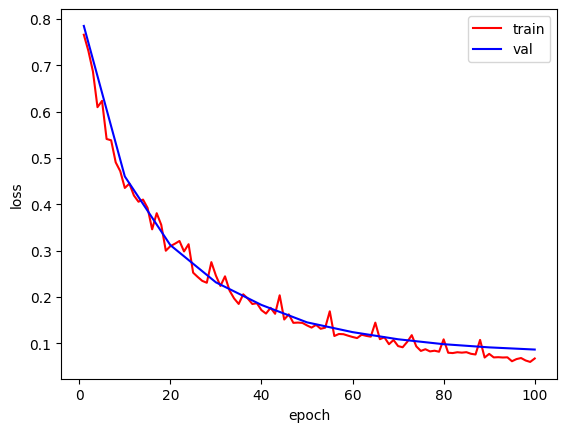

In [ ]:
model_dir = os.path.join(out_dir, 'model')
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

torch.manual_seed(rnd_seed) #fix random seed

model = SimpleNet3D(num_classes=num_classes).to(device)
model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_train_log = []
loss_val_log = []
epoch_val_log = []

print('START TRAINING...')
for epoch in range(1, num_epochs + 1):

    # Training
    for batch_idx, batch_samples in enumerate(dataloader_train):
        img, seg = batch_samples['img'].to(device), batch_samples['seg'].to(device)
        optimizer.zero_grad()
        prd = model(img)
        loss = F.cross_entropy(prd, seg.squeeze(1))
        loss.backward()
        optimizer.step()

    loss_train_log.append(loss.item())

    print('+ TRAINING \tEpoch: {} \tLoss: {:.6f}'.format(epoch, loss.item()))

    # Validation
    if epoch == 1 or epoch % val_interval == 0:
        loss_val = 0
        sum_pts = 0
        with torch.no_grad():
            for data_sample in dataloader_val:
                img, seg = data_sample['img'].to(device), data_sample['seg'].to(device)
                prd = model(img)
                loss_val += F.cross_entropy(prd, seg.squeeze(1), reduction='sum').item()
                sum_pts += np.prod(img_size)

        prd = torch.argmax(prd, dim=1)
        prediction = sitk.GetImageFromArray(prd.cpu().squeeze().numpy().astype(np.uint8))


        loss_val /= sum_pts

        loss_val_log.append(loss_val)
        epoch_val_log.append(epoch)

        print('--------------------------------------------------')
        print('+ VALIDATE \tEpoch: {} \tLoss: {:.6f}'.format(epoch, loss_val))
        display_image(sitk.LabelToRGB(prediction))
        print('--------------------------------------------------')

torch.save(model.state_dict(), os.path.join(model_dir, 'model.pt'))

print('\nFinished TRAINING.')

plt.plot(range(1, num_epochs + 1), loss_train_log, c='r', label='train')
plt.plot(epoch_val_log, loss_val_log, c='b', label='val')
plt.legend(loc='upper right')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

#### Loading and pre-processing of testing data

Now that we have trained a model, the next cells are about applying that model to the 500 subjects that are used for training the age regressor. Note, at a later stage you will also need to run the model on the 100 subjects from the hold-out set, once these have been made available. Before testing on the full set, you may want to initially just test on the 5 validation subjects to check everything is working fine.

In [22]:
meta_data_reg_train = pd.read_csv(data_dir + 'meta/meta_data_regression_train.csv')
ids_seg_test = list(meta_data_reg_train['subject_id'])
files_seg_img_test = [data_dir + 'images/sub-' + f + '_T1w_unbiased.nii.gz' for f in ids_seg_test]
files_seg_seg_test = [data_dir + 'segs_refs/sub-' + f + '_T1w_seg.nii.gz' for f in ids_seg_test]
files_seg_msk_test = [data_dir + 'masks/sub-' + f + '_T1w_brain_mask.nii.gz' for f in ids_seg_test]

dataset_test = ImageSegmentationDataset(files_seg_img_test, files_seg_seg_test, files_seg_msk_test, img_spacing, img_size)
dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=1, shuffle=False)

Loading Data: 100%|██████████| 500/500 [21:36<00:00,  2.59s/it]


#### Visualise testing example

Just to check how a testing image looks like after pre-processing.

Image: sub-CC520745_T1w_unbiased.nii.gz


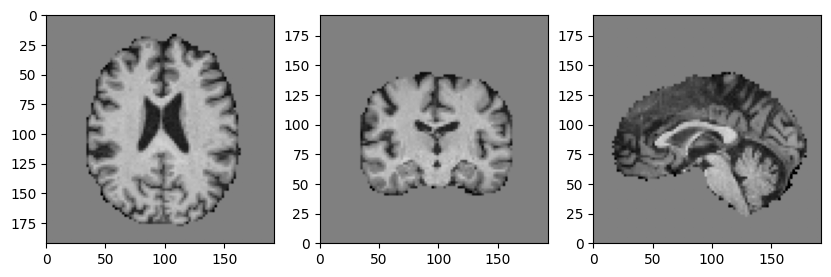

Segmentation


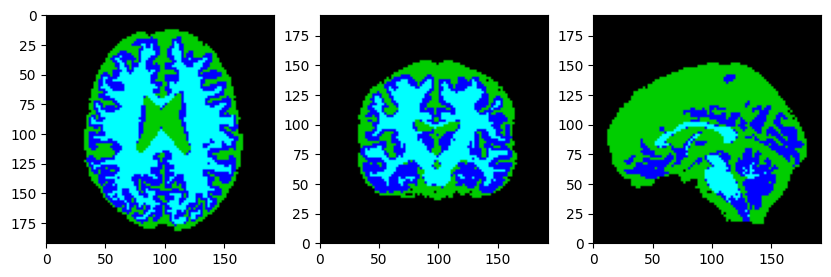

Mask


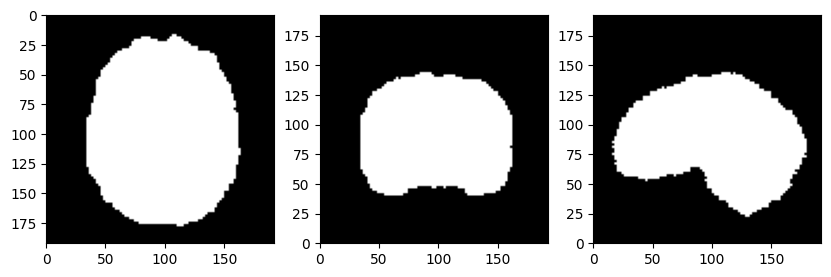

In [23]:
sample = dataset_test.get_sample(0)
img_name = dataset_test.get_img_name(0)
seg_name = dataset_test.get_seg_name(0)
print('Image: ' + img_name)
display_image(sample['img'], window=5, level=0)
print('Segmentation')
display_image(sitk.LabelToRGB(sample['seg']))
print('Mask')
display_image(sample['msk'])

#### TESTING

Below is an implementation of a full testing procedure that saves the segmentations in an output folder.
**TASK: You will need to add the calculations of Dice scores (and possibly other metrics) to evaluate the segmentation performance.**

In [47]:

pred_dir = os.path.join(out_dir, 'pred')
if not os.path.exists(pred_dir):
    os.makedirs(pred_dir)

model = SimpleNet3D(num_classes=num_classes)
model.load_state_dict(torch.load(os.path.join(model_dir, 'model.pt')))
model.to(device)
model.eval()

print('START TESTING...')

loss_test = 0
sum_pts = 0
idx_test = 0
dice_scores = []
dice_scores_csf = []
dice_scores_gm = []
dice_scores_wm = []

overlap_measures_filter = sitk.LabelOverlapMeasuresImageFilter()
with torch.no_grad():
    for data_sample in dataloader_test:
        img, seg = data_sample['img'].to(device), data_sample['seg'].to(device)
        prd = model(img)
        loss_test += F.cross_entropy(prd, seg.squeeze(1), reduction='sum').item()
        sum_pts += np.prod(img_size)

        prd = torch.argmax(prd, dim=1)

        sample = dataset_test.get_sample(idx_test)
        name = dataset_test.get_seg_name(idx_test)
        prediction = sitk.GetImageFromArray(prd.cpu().squeeze().numpy().astype(np.uint8))
        prediction.CopyInformation(sample['seg'])
        sitk.WriteImage(prediction, os.path.join(pred_dir, name))

        # Calculating overall dice score
        ref = sitk.GetImageFromArray(seg.cpu().squeeze().numpy().astype(np.uint8))
        ref.CopyInformation(sample['seg'])
        overlap_measures_filter.Execute(ref, prediction)
        dice_scores.append(overlap_measures_filter.GetDiceCoefficient())

        # Calculating dice per tissue
        prediction_csf = prediction == 1
        prediction_gm = prediction == 2
        prediction_wm = prediction == 3
        ref_csf = ref == 1
        ref_gm = ref == 2
        ref_wm = ref == 3

        overlap_measures_filter.Execute(ref_csf, prediction_csf)
        dice_scores_csf.append(overlap_measures_filter.GetDiceCoefficient())
        overlap_measures_filter.Execute(ref_gm, prediction_gm)
        dice_scores_gm.append(overlap_measures_filter.GetDiceCoefficient())
        overlap_measures_filter.Execute(ref_wm, prediction_wm)
        dice_scores_wm.append(overlap_measures_filter.GetDiceCoefficient())

        idx_test += 1

loss_test /= sum_pts

print('+ TESTING \tLoss: {:.6f}'.format(loss_test))

# Show last testing sample as an example
print('\n\nReference segmentation')
display_image(sitk.LabelToRGB(sample['seg']))
print('Predicted segmentation')
display_image(sitk.LabelToRGB(prediction))

plt.boxplot(dice_scores)
plt.title("Overall dice score")
plt.show()
plt.boxplot(dice_scores_csf)
plt.title("CSF dice score")
plt.show()
plt.boxplot(dice_scores_gm)
plt.title("GM dice score")
plt.show()
plt.boxplot(dice_scores_wm)
plt.title("WM dice score")
plt.show()

print('\nFinished TESTING.')

TypeError: expected str, bytes or os.PathLike object, not SimpleNet3D


### TASK A-2: Feature calculation

Start by calculating the three absolute tissue volumes for each subject. Plot the volumes against the subjects' ages. Taking the absolute volumes of tissues as features, however, might not be predictive. Instead, relative volumes need to be computed as the ratios between each tissue volume and overall brain volume. But you might also want to explore using different combinations or even polynomial features.

Implement a function that constructs a big matrix $X$ with a row for each subject and features across the columns. Start with just calculating three simple features of relative tissue volumes for GM, WM and CSF, and compare these to the absolute volumes plotted above.



In [27]:
## CALCULATE ABSOLUTE TISSUE VOLUMES

import os

# USE THIS TO RUN THE CALCULATIONS ON YOUR SEGMENTATONS
seg_dir = './output/pred/'

# USE THIS TO RUN THE CALCULATIONS ON OUR REFERENCE SEGMENTATIONS
#seg_dir = data_dir + 'segs_refs/'

meta_data_reg_train = pd.read_csv(data_dir + 'meta/meta_data_regression_train.csv')
ids_reg_train = list(meta_data_reg_train['subject_id'])
files_reg_seg_train = [seg_dir + 'sub-' + f + '_T1w_seg.nii.gz' for f in ids_reg_train]

# THIS MATRIX WILL STORE THE VOLUMES PER TISSUE CLASS
vols = np.zeros((3,len(files_reg_seg_train)))

for idx, _ in enumerate(tqdm(range(len(files_reg_seg_train)), desc='Calculating Features')):

    seg_filename = files_reg_seg_train[idx]

    if os.path.exists(seg_filename):
        seg = sitk.ReadImage(seg_filename)



        #display_image(sitk.LabelToRGB(seg))

        arr = sitk.GetArrayFromImage(seg)

        CSF = np.sum(arr == 1)
        GM = np.sum(arr == 2)
        WM = np.sum(arr == 3)

        vols[0, idx] = CSF
        vols[1, idx] = GM
        vols[2, idx] = WM


        ########################################

Calculating Features: 100%|██████████| 500/500 [00:00<00:00, 121271.73it/s]


Plot features versus age.

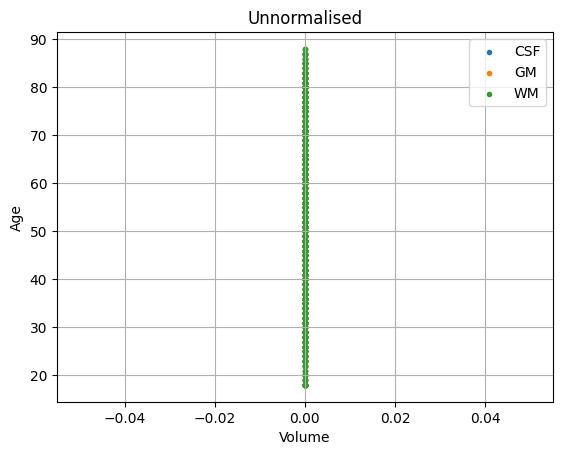

In [28]:
plt.scatter(vols[0,:],meta_data_reg_train['age'], marker='.')
plt.scatter(vols[1,:],meta_data_reg_train['age'], marker='.')
plt.scatter(vols[2,:],meta_data_reg_train['age'], marker='.')
plt.grid()
plt.title('Unnormalised')
plt.xlabel('Volume')
plt.ylabel('Age')
plt.legend(('CSF','GM','WM'))
plt.show()

In [48]:
## CALCULATE RELATIVE TISSUE VOLUMES

vols_normalised = np.zeros((3,len(files_reg_seg_train)))


for idx, _ in enumerate(tqdm(range(len(files_reg_seg_train)), desc='Calculating Relative Features')):

    seg_filename = files_reg_seg_train[idx]

    if os.path.exists(seg_filename):
        seg = sitk.ReadImage(seg_filename)

    arr = sitk.GetArrayFromImage(seg)

    CSF = np.sum(arr == 1)
    GM = np.sum(arr == 2)
    WM = np.sum(arr == 3)

    vols_normalised[0, idx] = CSF/(CSF+GM+WM)
    vols_normalised[1, idx] = GM/(CSF+GM+WM)
    vols_normalised[2, idx] = WM/(CSF+GM+WM)

########################################

Calculating Relative Features:   0%|          | 0/500 [00:00<?, ?it/s]


NameError: name 'seg' is not defined

Plot normalised features versus age.

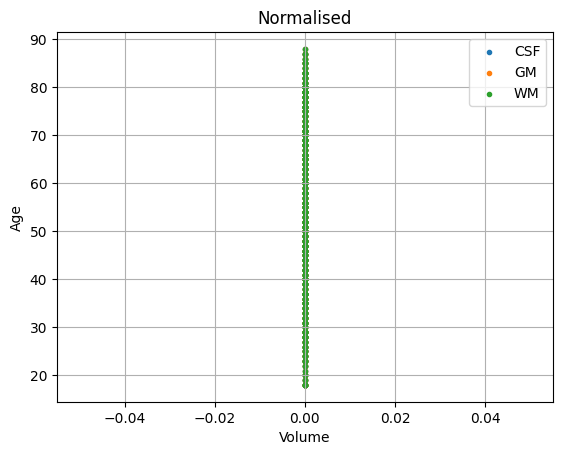

In [31]:
plt.scatter(vols_normalised[0,:],meta_data_reg_train['age'], marker='.')
plt.scatter(vols_normalised[1,:],meta_data_reg_train['age'], marker='.')
plt.scatter(vols_normalised[2,:],meta_data_reg_train['age'], marker='.')
plt.grid()
plt.title('Normalised')
plt.xlabel('Volume')
plt.ylabel('Age')
plt.legend(('CSF','GM','WM'))
plt.show()

Final data for age regression

In [32]:
X = vols_normalised.T
y = meta_data_reg_train['age'].values.reshape(-1,1)

print(X.shape)
print(y.shape)

(500, 3)
(500, 1)



### TASK A-3: Age regression and cross-validation


Evaluate the methods using two-fold [cross-validation](http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation) where the dataset of 500 subjects is split into two equally sized sets $(X_1,y_1)$ and $(X_2,y_2)$ which are used for training and testing in an alternating way (so each set is used as $(X_{\text{train}},y_{\text{train}})$ and $(X_{\text{test}},y_{\text{test}})$ exactly once).



LinearRegression
mean_absolute_error: 15.260639999999999
r2_score: -0.005638933431050708
mean_absolute_error: 16.53792
r2_score: -0.004857885950231067


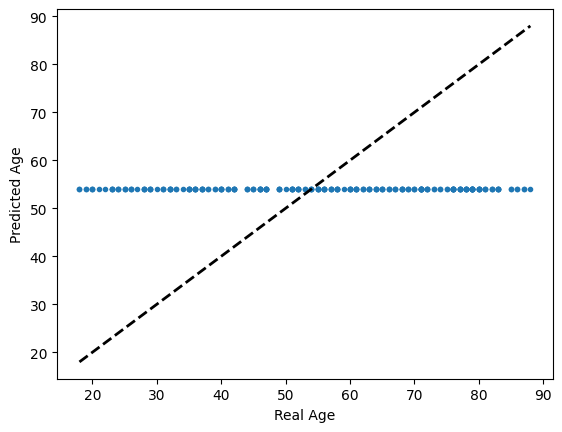

BayesianRidge
mean_absolute_error: 15.260639999999999
r2_score: -0.005638933431050708
mean_absolute_error: 16.53792
r2_score: -0.004857885950231067


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


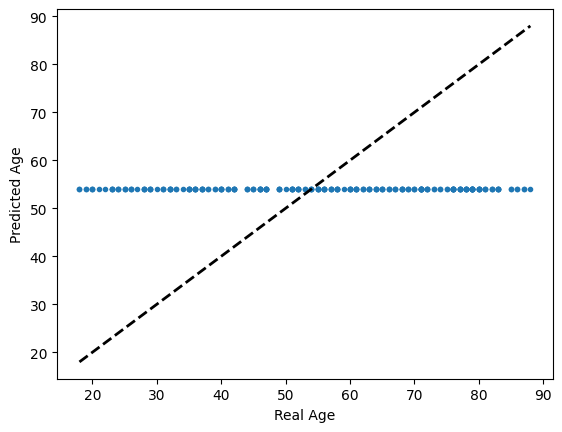

Lasso
mean_absolute_error: 15.260639999999999
r2_score: -0.005638933431050708
mean_absolute_error: 16.53792
r2_score: -0.004857885950231067


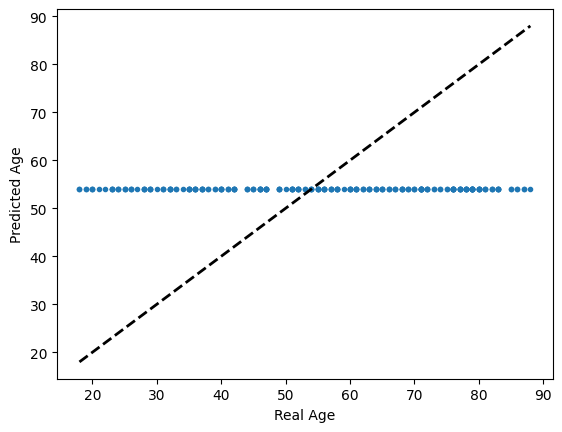

LassoLars
mean_absolute_error: 15.260639999999999
r2_score: -0.005638933431050708
mean_absolute_error: 16.53792
r2_score: -0.004857885950231067


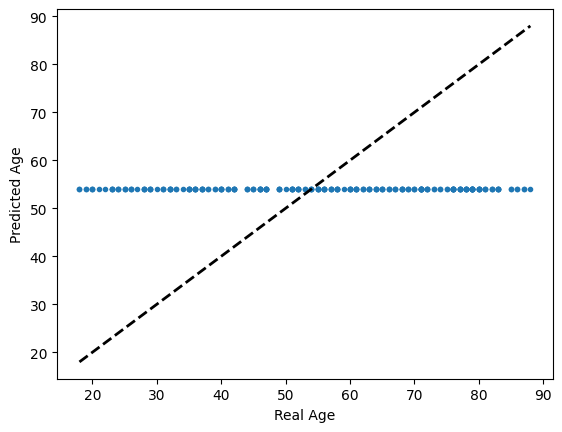

Average MAE: 15.89928
Average R2 Score: -0.005248409690640887


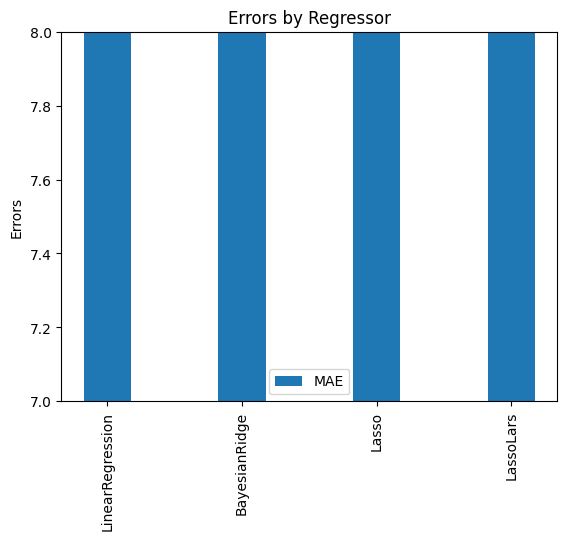

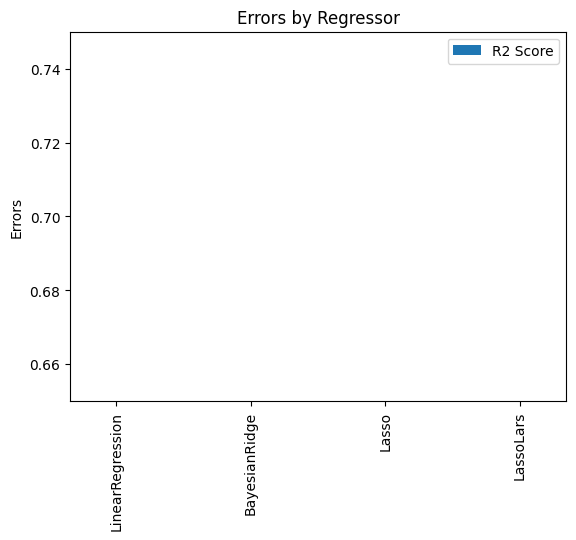

In [33]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression, BayesianRidge, Lasso, LassoLars
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.metrics import mean_absolute_error, r2_score
def get_error_metrics(predicted, y):
    error_metrics = {}
    for error_metric in [mean_absolute_error, r2_score]:
        name = error_metric.__name__
        error = error_metric(y, predicted)
        print((name+': {0}').format(error))
        error_metrics[error_metric] = error
    return error_metrics[mean_absolute_error], error_metrics[r2_score]

def plot_results(predicted, y, title=""):
    fig, ax = plt.subplots()
    ax.scatter(y, predicted, marker='.')
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
    ax.set_xlabel('Real Age')
    ax.set_ylabel('Predicted Age')
    ax.set_title(title)
    plt.show()

def train_k_fold(regressor, X, y, kf, plot=True, K=2):
    errors = []
    for train, test in kf.split(X):
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
        regressor.fit(X_train, y_train)
        predicted = regressor.predict(X_test)
        mae, r2 = get_error_metrics(predicted, y_test)
        errors.append({"MAE": mae, "R2 Score": r2})
    if plot:
        plot_results(predicted, y_test)
        average_mae = np.mean([errors[0]["MAE"], errors[1]["MAE"]])
        average_r2 = np.mean([errors[0]["R2 Score"], errors[1]["R2 Score"]])
    return average_mae, average_r2

def update_error_metrics(error_metrics, regressor_name, mae, r2):
    error_metrics["MAE"] = error_metrics.get("MAE", {})
    error_metrics["R2 Score"] = error_metrics.get("R2 Score", {})
    error_metrics["MAE"][regressor_name] = mae
    error_metrics["R2 Score"][regressor_name] = r2
    return error_metrics

regressors = [LinearRegression(), BayesianRidge(), Lasso(alpha=0.01), LassoLars(alpha=.01)]
regressor_names = [x.__class__.__name__ for x in regressors]
K=2
kf = KFold(n_splits=K, shuffle=True, random_state = 2)
error_metrics = {}

for i, regressor in enumerate(regressors):
    regressor_name = regressor_names[i]
    print(regressor_name)
    mae, r2 = train_k_fold(regressor, X, y, kf)
    error_metrics = update_error_metrics(error_metrics, regressor_name, mae, r2)

print("Average MAE: " + str(mae))
print("Average R2 Score: " + str(r2))


def bar_plot(error_metrics, regressor_names, error, ymin, ymax):
    width = 0.35
    x = np.arange(len(regressor_names))
    fig, ax = plt.subplots()
    ax.bar(x, error_metrics[error].values(), width, label=error)

    ax.set_ylabel('Errors')
    ax.set_title('Errors by Regressor')
    ax.set_xticks(x)
    ax.set_ylim([ymin,ymax])
    ax.set_xticklabels(regressor_names)
    ax.legend()

    plt.xticks(rotation=90)

bar_plot(error_metrics, regressor_names, "MAE", 7,8)
bar_plot(error_metrics, regressor_names, "R2 Score", 0.65,0.75)


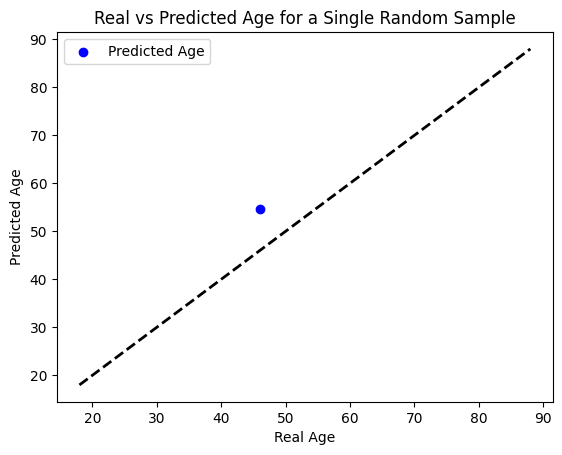

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Initialize and train the regressor using the entire dataset
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict age for a single random sample from the test set
random_index = np.random.randint(0, len(X_test))
random_sample = X_test[random_index].reshape(1, -1)
predicted_age = regressor.predict(random_sample)[0]

# Plot the graph for real vs predicted ages for the single random sample
plt.scatter(y_test[random_index], predicted_age, color='blue', label='Predicted Age')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Real Age')
plt.ylabel('Predicted Age')
plt.title('Real vs Predicted Age for a Single Random Sample')
plt.legend()
plt.show()


In [35]:
# Print the real age and its predicted value
real_age = y_test[random_index]
print("Real Age:", real_age)
print("Predicted Age:", predicted_age)
# Calculate the brain age gap
brain_age_gap = real_age - predicted_age
print("Brain Age Gap:", brain_age_gap)


Real Age: [46]
Predicted Age: [54.724]
Brain Age Gap: [-8.724]
